# Funding-Rate Carry with a Scalar Kalman Filter
## An annotated, step-by-step notebook

This notebook decomposes the program into individual components:

1. Load hourly BTC perpetual funding-rate data from Kraken or a local cache.
2. Understand the carry trade: long spot + short perpetual.
3. Model noisy funding with a one-dimensional Kalman filter.
4. Inspect one Kalman update by hand.
5. Filter the full series and visualise smoothing behaviour.
6. Convert the filtered estimate into a cost-aware position signal.
7. Backtest without look-ahead bias.
8. Tune the smoothing parameter on a training period only.
9. Evaluate on a held-out test period.
10. Examine limitations and possible improvements.

The notebook mirrors the logic of `funding_carry.py`, but exposes intermediate objects such as the innovation, Kalman gain, predicted variance, posterior variance, positions, turnover, and per-bar P&L.

## 0. Strategy in one picture

The trade is intended to be approximately delta neutral:

$$
\mathrm{position} = +1\,\mathrm{BTC}_{\mathrm{spot}} - 1\,\mathrm{BTC}_{\mathrm{perp}}
$$

If the funding rate is positive, the short perpetual leg receives funding. In this simplified research model:

$$
\mathrm{PnL}^{\mathrm{gross}}_t =
\begin{cases}
f_t N, & \mathrm{open}\\
0, & \mathrm{flat}
\end{cases}
$$

where $f_t$ is the realised relative funding rate and $N$ is notional.

The Kalman filter does **not** create the arbitrage. It estimates whether the funding level is sufficiently persistent and positive to justify paying trading costs.

In [2]:
# Imports and configuration
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.8f}")

CSV_PATH = Path("funding_xbtusd.csv")
SYMBOL = "PF_XBTUSD"

# Trading/cost assumptions from the original script
ROUND_TRIP_COST = 0.0024     # 24 bps total entry+exit cost across both legs
TRAIN_FRAC = 0.40
HOLD_HOURS_FOR_BREAKEVEN = 168  # one-week yardstick
ENTRY_MULT = 2.0
EXIT_MULT = 0.5

# Baseline filter beliefs from the original script
Q_BELIEF = 1e-13
R_BELIEF = 7e-11

# Set True to study the notebook without downloading Kraken data.
# The real strategy analysis should use the Kraken data.
USE_SYNTHETIC_DATA = False

print("Configuration loaded.")

Configuration loaded.


## 1. Load the funding-rate observations

The observed variable is $z_t$: the relative BTC perpetual funding rate observed at time $t$.

The relative funding rate is expressed as a fraction of notional per funding interval. For example, $0.00001$ represents one basis point of notional.

The cell below first looks for a cached CSV. When the CSV is absent, it requests historical funding rates from Kraken and caches them locally. A synthetic fallback is provided only so that the filter mechanics can be explored without an internet connection.

In [3]:
def make_synthetic_funding(n: int = 2400, seed: int = 7) -> pd.DataFrame:
    """Create illustrative noisy funding regimes when real data are unavailable.

    The high-funding regimes are deliberately above the cost-aware entry
    threshold so that entries, exits, transaction costs, and P&L are visible
    when studying the notebook offline.
    """
    rng = np.random.default_rng(seed)
    t = np.arange(n)
    high_regime = (t % 480) < 240
    target_level = np.where(high_regime, 4.8e-5, 2.0e-6)

    latent = np.zeros(n)
    latent[0] = target_level[0]
    for i in range(1, n):
        drift_toward_regime = 0.04 * (target_level[i] - latent[i - 1])
        latent[i] = latent[i - 1] + drift_toward_regime + rng.normal(0, 6e-7)

    observations = latent + rng.normal(0, 8e-6, n)
    idx = pd.date_range("2025-01-01", periods=n, freq="h", tz="UTC")
    return pd.DataFrame({"funding": observations, "latent_for_demo_only": latent}, index=idx)


def load_funding(csv_path: Path = CSV_PATH, symbol: str = SYMBOL, synthetic: bool = False) -> pd.DataFrame:
    if synthetic:
        print("Using synthetic funding observations for learning purposes.")
        return make_synthetic_funding()

    if csv_path.exists():
        raw = pd.read_csv(csv_path, index_col=0, parse_dates=True)
        print(f"Loaded {len(raw):,} cached rows from {csv_path}.")
    else:
        import requests

        url = "https://futures.kraken.com/derivatives/api/v4/historical-funding-rates"
        response = requests.get(url, params={"symbol": symbol}, timeout=30)
        response.raise_for_status()
        raw = pd.DataFrame(response.json()["rates"])
        raw["timestamp"] = pd.to_datetime(raw["timestamp"], utc=True)
        raw = raw.set_index("timestamp").sort_index()
        raw.to_csv(csv_path)
        print(f"Downloaded and cached {len(raw):,} Kraken rows to {csv_path}.")

    if "relativeFundingRate" in raw.columns:
        out = raw[["relativeFundingRate"]].rename(columns={"relativeFundingRate": "funding"})
    elif "funding" in raw.columns:
        out = raw[["funding"]].copy()
    else:
        raise KeyError("Expected a 'relativeFundingRate' or 'funding' column.")

    return out.dropna()


try:
    funding_df = load_funding(synthetic=USE_SYNTHETIC_DATA)
except Exception as exc:
    print(f"Real-data load failed: {type(exc).__name__}: {exc}")
    print("Falling back to synthetic data. Set USE_SYNTHETIC_DATA=True intentionally for repeated offline use.")
    funding_df = load_funding(synthetic=True)

funding_df.head()

Loaded 8,783 cached rows from funding_xbtusd.csv.


,funding
timestamp,
2025-05-28 08:00:00+00:00,0.00000905
2025-05-28 09:00:00+00:00,0.00000811
2025-05-28 10:00:00+00:00,0.00000926
2025-05-28 11:00:00+00:00,0.00000755
2025-05-28 12:00:00+00:00,0.00000742


In [4]:
import requests
url = "https://futures.kraken.com/derivatives/api/v4/historical-funding-rates"
response = requests.get(url, params={"symbol": SYMBOL}, timeout=30)
response.raise_for_status()
raw = pd.DataFrame(response.json()["rates"])

In [5]:
a = raw.items()

In [6]:
try:
    print(next(a))
except StopIteration:
    a = raw.items()

('timestamp', 0       2025-05-28T08:00:00Z
1       2025-05-28T09:00:00Z
2       2025-05-28T10:00:00Z
3       2025-05-28T11:00:00Z
4       2025-05-28T12:00:00Z
                ...         
8800    2026-05-30T10:00:00Z
8801    2026-05-30T11:00:00Z
8802    2026-05-30T12:00:00Z
8803    2026-05-30T13:00:00Z
8804    2026-05-30T14:00:00Z
Name: timestamp, Length: 8805, dtype: str)


,value
bars,"8,783.00000000"
mean funding per bar,0.00000562
standard deviation per bar,0.00000848
minimum,-0.00017729
maximum,0.00004552
fraction positive,0.76955482


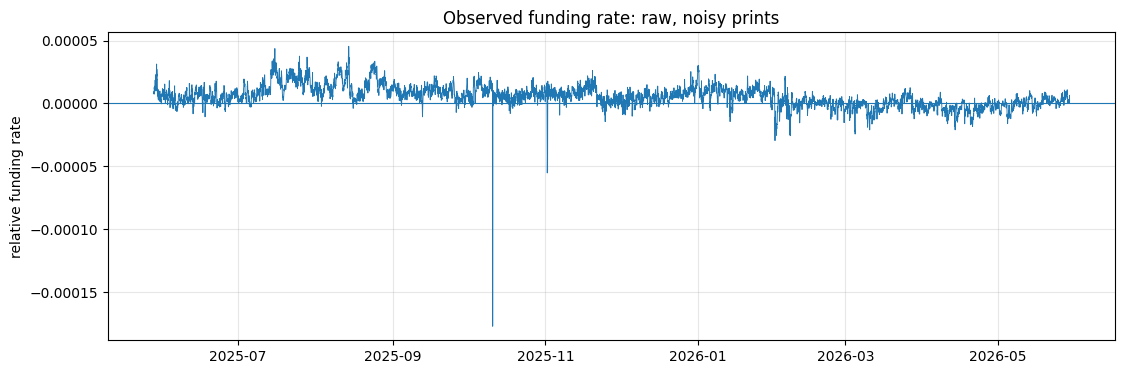

In [7]:
# Raw data inspection
funding = funding_df["funding"].to_numpy(dtype=float)

raw_summary = pd.Series({
    "bars": len(funding),
    "mean funding per bar": funding.mean(),
    "standard deviation per bar": funding.std(),
    "minimum": funding.min(),
    "maximum": funding.max(),
    "fraction positive": (funding > 0).mean(),
})
display(raw_summary.to_frame("value"))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(funding_df.index, funding_df["funding"], linewidth=0.65)
ax.axhline(0, linewidth=0.8)
ax.set_title("Observed funding rate: raw, noisy prints")
ax.set_ylabel("relative funding rate")
ax.grid(alpha=0.3)
plt.show()

## 2. The state-space model

We assume there is an unobserved underlying funding level $x_t$, while Kraken gives us a noisy observation $z_t$.

**State evolution:**

$$
x_t = x_{t-1} + w_t, \qquad w_t \sim \mathcal{N}(0, Q)
$$

The underlying funding level is assumed to drift as a random walk. $Q$ determines how quickly it may change.

**Measurement equation:**

$$
z_t = x_t + v_t, \qquad v_t \sim \mathcal{N}(0, R)
$$

$R$ determines how noisy we think an individual observed print is.

Interpretation:

| Parameter | Small value | Large value |
|---|---|---|
| $Q$ | True funding changes slowly; smoother estimate | True funding can move quickly; responsive estimate |
| $R$ | Trust each new observation | Distrust each observation; stronger smoothing |

In this scalar random-walk filter, the smoothing behaviour is driven mainly by the ratio $Q/R$.

## 3. One Kalman step, exposed line by line

At time $t$, the filter first predicts:

$$
x_{\mathrm{pred},t} = \hat{x}_{t-1}
$$

$$
P_{\mathrm{pred},t} = P_{t-1} + Q
$$

Then it observes $z_t$ and updates:

$$
\nu_t = z_t - x_{\mathrm{pred},t}
$$

$$
K_t = \frac{P_{\mathrm{pred},t}}{P_{\mathrm{pred},t} + R}
$$

$$
\hat{x}_t = x_{\mathrm{pred},t} + K_t\nu_t
$$

$$
P_t = (1-K_t)P_{\mathrm{pred},t}
$$

The Kalman gain $K_t$ controls how much the estimate moves toward the latest observation.

In [8]:
def kalman_step_detailed(x_previous: float, P_previous: float, z: float, Q: float, R: float) -> dict:
    """Perform one scalar Kalman predict/update step and return every intermediate value."""
    x_pred = x_previous
    P_pred = P_previous + Q

    innovation = z - x_pred
    K = P_pred / (P_pred + R)

    x_hat = x_pred + K * innovation
    P_hat = (1.0 - K) * P_pred

    return {
        "x_previous": x_previous,
        "P_previous": P_previous,
        "observation_z": z,
        "Q": Q,
        "R": R,
        "x_pred": x_pred,
        "P_pred": P_pred,
        "innovation": innovation,
        "kalman_gain_K": K,
        "x_hat": x_hat,
        "P_hat": P_hat,
    }


# Use an early observation to inspect the arithmetic of one step.
example_x = funding[0]
example_P = R_BELIEF
example_z = funding[1]

one_step = kalman_step_detailed(example_x, example_P, example_z, Q_BELIEF, R_BELIEF)
display(pd.Series(one_step).to_frame("value"))

print(f"The estimate moved {one_step['kalman_gain_K']:.2%} of the way from the prediction toward the new observation.")

,value
x_previous,0.00000905
P_previous,0.00000000
observation_z,0.00000811
Q,0.00000000
R,0.00000000
x_pred,0.00000905
P_pred,0.00000000
innovation,-0.00000093
kalman_gain_K,0.50035689
x_hat,0.00000858


The estimate moved 50.04% of the way from the prediction toward the new observation.


## 4. Run the filter through the whole series

The function below returns more than the final smoothed series. It records every intermediate quantity so that the mechanics can be graphed and inspected bar by bar.

In [9]:
def filter_with_diagnostics(z: np.ndarray, Q: float, R: float, initial_P: float = 1.0) -> pd.DataFrame:
    """Run the scalar filter and record estimate, variance, gain, and innovation at every observation."""
    z = np.asarray(z, dtype=float)
    if z.size == 0:
        raise ValueError("The observation series is empty.")

    records = []
    x = z[0]
    P = initial_P

    for t, observation in enumerate(z):
        result = kalman_step_detailed(x, P, observation, Q, R)
        records.append(result)
        x = result["x_hat"]
        P = result["P_hat"]

    return pd.DataFrame(records)


diag = filter_with_diagnostics(funding, Q_BELIEF, R_BELIEF)
diag.index = funding_df.index
diag[["observation_z", "x_hat", "innovation", "kalman_gain_K", "P_hat"]].head(10)

,observation_z,x_hat,innovation,kalman_gain_K,P_hat
timestamp,,,,,
2025-05-28 08:00:00+00:00,0.00000905,0.00000905,0.00000000,1.00000000,0.00000000
2025-05-28 09:00:00+00:00,0.00000811,0.00000858,-0.00000093,0.50035691,0.00000000
2025-05-28 10:00:00+00:00,0.00000926,0.00000880,0.00000068,0.33412594,0.00000000
2025-05-28 11:00:00+00:00,0.00000755,0.00000849,-0.00000126,0.25124733,0.00000000
2025-05-28 12:00:00+00:00,0.00000742,0.00000827,-0.00000107,0.20170892,0.00000000
2025-05-28 13:00:00+00:00,0.00001265,0.00000901,0.00000437,0.16883980,0.00000000
2025-05-28 14:00:00+00:00,0.00001186,0.00000943,0.00000285,0.14549515,0.00000000
2025-05-28 15:00:00+00:00,0.00001339,0.00000993,0.00000396,0.12810243,0.00000000
2025-05-28 16:00:00+00:00,0.00001308,0.00001030,0.00000314,0.11467680,0.00000000


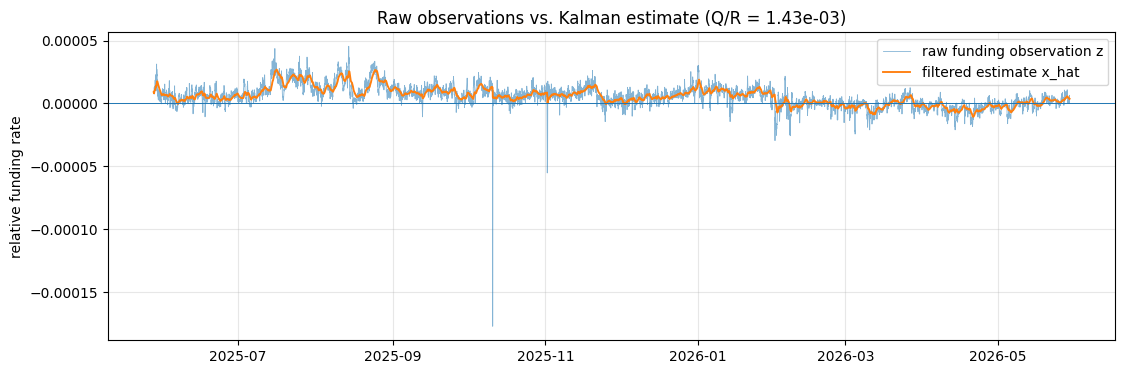

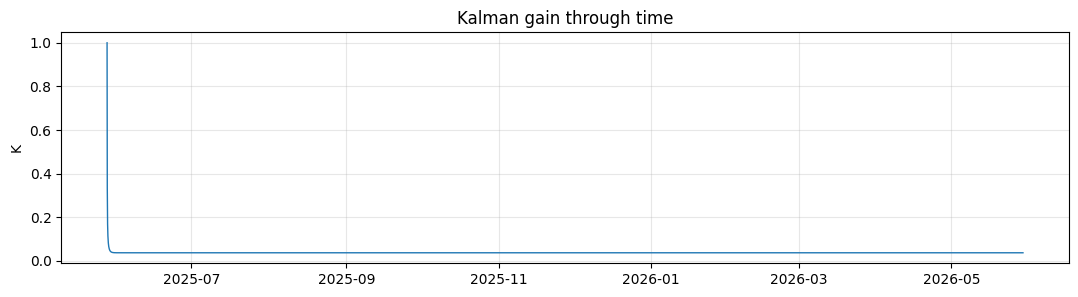

,observation_z,x_hat,innovation,kalman_gain_K,P_pred,P_hat
timestamp,,,,,,
2026-05-29 12:00:00+00:00,0.00000004,0.00000372,-0.00000382,0.03708891,0.00000000,0.00000000
2026-05-29 13:00:00+00:00,0.00000234,0.00000367,-0.00000138,0.03708891,0.00000000,0.00000000
2026-05-29 14:00:00+00:00,0.00000567,0.00000374,0.00000200,0.03708891,0.00000000,0.00000000
2026-05-29 15:00:00+00:00,0.00000656,0.00000385,0.00000281,0.03708891,0.00000000,0.00000000
2026-05-29 16:00:00+00:00,0.00000132,0.00000375,-0.00000253,0.03708891,0.00000000,0.00000000


In [10]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(funding_df.index, funding, linewidth=0.6, alpha=0.55, label="raw funding observation z")
ax.plot(diag.index, diag["x_hat"], linewidth=1.35, label="filtered estimate x_hat")
ax.axhline(0, linewidth=0.7)
ax.set_title(f"Raw observations vs. Kalman estimate (Q/R = {Q_BELIEF / R_BELIEF:.2e})")
ax.set_ylabel("relative funding rate")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(diag.index, diag["kalman_gain_K"], linewidth=1.0)
ax.set_title("Kalman gain through time")
ax.set_ylabel("K")
ax.grid(alpha=0.3)
plt.show()

display(diag[["observation_z", "x_hat", "innovation", "kalman_gain_K", "P_pred", "P_hat"]].tail())

## 5. See the effect of changing $Q/R$

Rather than treating $Q$ and $R$ as abstract values, compare several smoothing choices directly:

- Low $Q/R$: the hidden funding level is assumed to move slowly.
- High $Q/R$: the hidden funding level is allowed to respond quickly to new funding prints.

The original strategy searches over values of $Q/R$ on the training set.

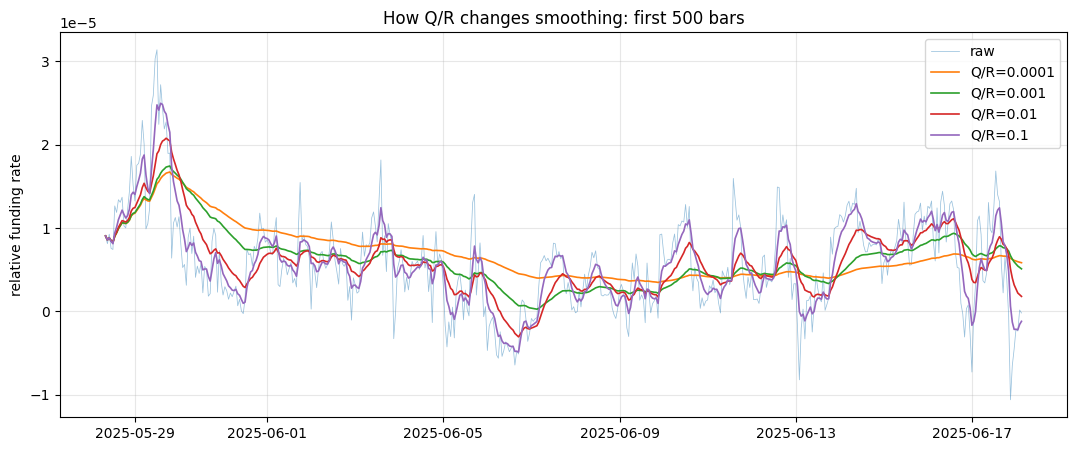

,ending Kalman gain,std of filtered estimate
Q/R,,
0.00010000,0.00995012,0.00000617
0.00100000,0.03112673,0.00000672
0.01000000,0.09512492,0.00000726
0.10000000,0.27015621,0.00000776


In [11]:
q_over_r_values = [1e-4, 1e-3, 1e-2, 1e-1]

comparison = pd.DataFrame({"raw funding": funding}, index=funding_df.index)
gain_summary = []

for ratio in q_over_r_values:
    Q = ratio * R_BELIEF
    d = filter_with_diagnostics(funding, Q, R_BELIEF)
    comparison[f"filtered Q/R={ratio:g}"] = d["x_hat"].to_numpy()
    gain_summary.append({
        "Q/R": ratio,
        "ending Kalman gain": d["kalman_gain_K"].iloc[-1],
        "std of filtered estimate": d["x_hat"].std(),
    })

# Plot a bounded window so the smoothing differences remain visible.
window = min(500, len(comparison))
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(comparison.index[:window], comparison["raw funding"].iloc[:window], linewidth=0.55, alpha=0.45, label="raw")
for ratio in q_over_r_values:
    ax.plot(comparison.index[:window], comparison[f"filtered Q/R={ratio:g}"].iloc[:window], linewidth=1.2, label=f"Q/R={ratio:g}")
ax.set_title(f"How Q/R changes smoothing: first {window} bars")
ax.set_ylabel("relative funding rate")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

display(pd.DataFrame(gain_summary).set_index("Q/R"))

## 6. Costs and trading thresholds

A positive filtered funding rate is insufficient on its own. Opening and closing both legs costs money.

Let $\theta_{\mathrm{BE}}$ be the simplified cost break-even yardstick:

$$
\theta_{\mathrm{BE}} = \frac{c_{\mathrm{roundtrip}}}{h_{\mathrm{hold}}}
$$

The rule applies two thresholds:

$$
\theta_{\mathrm{entry}} = 2.0\,\theta_{\mathrm{BE}}
$$

$$
\theta_{\mathrm{exit}} = 0.5\,\theta_{\mathrm{BE}}
$$

Using a higher entry threshold and lower exit threshold creates **hysteresis**. It prevents frequent entry/exit changes when the estimated funding level hovers close to the cost boundary.

In [12]:
breakeven_per_hour = ROUND_TRIP_COST / HOLD_HOURS_FOR_BREAKEVEN
entry_threshold = ENTRY_MULT * breakeven_per_hour
exit_threshold = EXIT_MULT * breakeven_per_hour

threshold_table = pd.Series({
    "round-trip cost": ROUND_TRIP_COST,
    "holding-period yardstick in hours": HOLD_HOURS_FOR_BREAKEVEN,
    "break-even per hour": breakeven_per_hour,
    "entry threshold": entry_threshold,
    "exit threshold": exit_threshold,
})
display(threshold_table.to_frame("value"))

print(f"Raw bars above break-even: {(funding > breakeven_per_hour).mean():.2%}")

,value
round-trip cost,0.00240000
holding-period yardstick in hours,168.00000000
break-even per hour,0.00001429
entry threshold,0.00002857
exit threshold,0.00000714


Raw bars above break-even: 12.47%


## 7. Position rule and backtest alignment

Position convention:

- `pos = 1`: long spot and short perpetual.
- `pos = 0`: flat.

The important time alignment is:

$$
\mathrm{position}_t \longrightarrow \mathrm{funding}_{t+1}
$$

This is why the P&L code uses `pos[:-1] * funding[1:]`. Using a decision made after seeing $z_t$ to earn $z_t$ would make the backtest look ahead.

In [13]:
def make_positions(x_hat: np.ndarray, entry_thr: float, exit_thr: float) -> np.ndarray:
    """Turn the filtered estimate into a 0/1 carry position with hysteresis."""
    x_hat = np.asarray(x_hat, dtype=float)
    pos = np.zeros(len(x_hat))

    for t in range(1, len(x_hat)):
        if pos[t - 1] == 0:
            pos[t] = 1.0 if x_hat[t] > entry_thr else 0.0
        else:
            pos[t] = 0.0 if x_hat[t] < exit_thr else 1.0

    return pos


def backtest(
    funding: np.ndarray,
    x_hat: np.ndarray,
    entry_thr: float,
    exit_thr: float,
    round_trip_cost: float = ROUND_TRIP_COST,
    index=None,
) -> pd.DataFrame:
    """Calculate positions, correctly lagged funding P&L, costs, and equity."""
    pos = make_positions(x_hat, entry_thr, exit_thr)

    pnl_gross = np.zeros(len(funding))
    pnl_gross[1:] = pos[:-1] * funding[1:]  # no look-ahead: yesterday's decision earns today's funding

    turnover = np.abs(np.diff(pos, prepend=0.0))
    costs = (round_trip_cost / 2.0) * turnover
    pnl = pnl_gross - costs

    return pd.DataFrame({
        "funding": funding,
        "x_hat": x_hat,
        "pos": pos,
        "turnover": turnover,
        "pnl_gross": pnl_gross,
        "costs": costs,
        "pnl": pnl,
        "equity": np.cumsum(pnl),
    }, index=index)


baseline_bt = backtest(
    funding=funding,
    x_hat=diag["x_hat"].to_numpy(),
    entry_thr=entry_threshold,
    exit_thr=exit_threshold,
    index=funding_df.index,
)

baseline_bt.head(12)

,funding,x_hat,pos,turnover,pnl_gross,costs,pnl,equity
timestamp,,,,,,,,
2025-05-28 08:00:00+00:00,0.00000905,0.00000905,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
2025-05-28 09:00:00+00:00,0.00000811,0.00000858,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
2025-05-28 10:00:00+00:00,0.00000926,0.00000880,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
2025-05-28 11:00:00+00:00,0.00000755,0.00000849,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
2025-05-28 12:00:00+00:00,0.00000742,0.00000827,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
2025-05-28 13:00:00+00:00,0.00001265,0.00000901,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
2025-05-28 14:00:00+00:00,0.00001186,0.00000943,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
2025-05-28 15:00:00+00:00,0.00001339,0.00000993,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
2025-05-28 16:00:00+00:00,0.00001308,0.00001030,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000


In [14]:
# A small table designed to make the time lag visible.
event_rows = baseline_bt.index[(baseline_bt["turnover"] > 0)].tolist()
if event_rows:
    first_change_loc = baseline_bt.index.get_loc(event_rows[0])
    start = max(0, first_change_loc - 2)
    stop = min(len(baseline_bt), first_change_loc + 4)
    display(baseline_bt.iloc[start:stop][["funding", "x_hat", "pos", "turnover", "pnl_gross", "costs", "pnl"]])
else:
    print("There were no position changes under the baseline thresholds and filter parameters.")

There were no position changes under the baseline thresholds and filter parameters.


## 8. Performance report function

Sharpe ratio here is calculated from hourly P&L and annualised using $24\times365$ bars per year. Let $r_t$ be hourly P&L as a fraction of notional:

$$
\mathrm{Sharpe} =
\frac{\operatorname{mean}(r_t)}{\operatorname{std}(r_t)}
\sqrt{24\times365}
$$

This simple implementation does not subtract a risk-free rate.

In [15]:
def performance_report(bt: pd.DataFrame, label: str) -> pd.Series:
    pnl = bt["pnl"].to_numpy()
    equity = bt["equity"].to_numpy()
    pos = bt["pos"].to_numpy()

    entries = int((np.diff(pos) > 0).sum())
    sd = pnl.std()
    sharpe = pnl.mean() / sd * np.sqrt(24 * 365) if sd > 0 else np.nan
    running_peak = np.maximum.accumulate(equity) if len(equity) else np.array([])
    max_drawdown = (equity - running_peak).min() if len(equity) else 0.0

    result = pd.Series({
        "bars": len(bt),
        "entries": entries,
        "time in position": pos.mean() if len(pos) else np.nan,
        "gross P&L (fraction of notional)": bt["pnl_gross"].sum(),
        "cost drag": bt["costs"].sum(),
        "net P&L (fraction of notional)": equity[-1] if len(equity) else 0.0,
        "annualised Sharpe": sharpe,
        "max drawdown": max_drawdown,
    }, name=label)
    return result


display(performance_report(baseline_bt, "Baseline parameters").to_frame())

,Baseline parameters
bars,"8,783.00000000"
entries,0.00000000
time in position,0.00000000
gross P&L (fraction of notional),0.00000000
cost drag,0.00000000
net P&L (fraction of notional),0.00000000
annualised Sharpe,NaN
max drawdown,0.00000000


## 9. Train/test split

Parameters must not be chosen after seeing the period used for headline evaluation.

- **Training slice:** select the smoothing level $Q/R$.
- **Test slice:** evaluate the frozen decision rule on unseen historical data.

The filter remains causal: at each bar it uses only current and previous observed funding prints. Running it through the full chronological sequence is valid because no future observation enters an earlier estimate.

Training bars: 3,513 (40%)
Test bars:     5,270 (60%)
Split timestamp: 2025-10-21 19:00:00+00:00


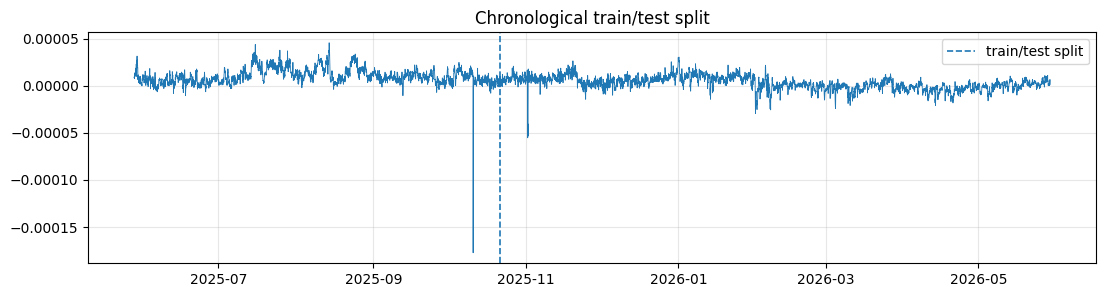

In [16]:
split_idx = int(len(funding) * TRAIN_FRAC)
train_funding = funding[:split_idx]
test_funding = funding[split_idx:]

print(f"Training bars: {len(train_funding):,} ({TRAIN_FRAC:.0%})")
print(f"Test bars:     {len(test_funding):,} ({1 - TRAIN_FRAC:.0%})")
print(f"Split timestamp: {funding_df.index[split_idx] if split_idx < len(funding_df) else 'n/a'}")

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(funding_df.index, funding, linewidth=0.6)
ax.axvline(funding_df.index[split_idx], linestyle="--", linewidth=1.2, label="train/test split")
ax.set_title("Chronological train/test split")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 10. Tune $Q/R$ on training data only

The original program does not statistically estimate the true $Q$ and $R$. Instead, it holds $R$ fixed, tries several $Q/R$ ratios, and chooses the smoothing behaviour that produced the best training Sharpe after costs.

This is a strategy-parameter search. It is kept separate from the held-out test period.

In [17]:
def tune_q_over_r_on_train(
    funding_train: np.ndarray,
    R: float,
    entry_thr: float,
    exit_thr: float,
    candidate_ratios=None,
) -> tuple[float, float, pd.DataFrame]:
    if candidate_ratios is None:
        candidate_ratios = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]

    results = []
    for ratio in candidate_ratios:
        Q = ratio * R
        d = filter_with_diagnostics(funding_train, Q, R)
        bt = backtest(funding_train, d["x_hat"].to_numpy(), entry_thr, exit_thr)
        metrics = performance_report(bt, f"Q/R={ratio:g}")
        results.append({
            "Q/R": ratio,
            "Q": Q,
            "R": R,
            "annualised Sharpe": metrics["annualised Sharpe"],
            "net P&L": metrics["net P&L (fraction of notional)"],
            "entries": metrics["entries"],
            "time in position": metrics["time in position"],
        })

    search_results = pd.DataFrame(results).sort_values("annualised Sharpe", ascending=False).reset_index(drop=True)
    best_ratio = float(search_results.loc[0, "Q/R"])
    best_Q = best_ratio * R
    return best_Q, R, search_results


best_Q, best_R, tuning_results = tune_q_over_r_on_train(
    train_funding,
    R=R_BELIEF,
    entry_thr=entry_threshold,
    exit_thr=exit_threshold,
)

display(tuning_results)
print(f"Selected on training data only: Q/R = {best_Q / best_R:g}")

,Q/R,Q,R,annualised Sharpe,net P&L,entries,time in position
0,0.00300000,0.00000000,0.00000000,4.66931379,0.00512766,1.00000000,0.12553373
1,0.01000000,0.00000000,0.00000000,2.71020972,0.00511475,3.00000000,0.21434671
2,0.10000000,0.00000000,0.00000000,0.27835915,0.00060341,4.00000000,0.15058355
3,0.03000000,0.00000000,0.00000000,-1.07447998,-0.00200974,3.00000000,0.08340450
4,0.00010000,0.00000000,0.00000000,NaN,0.00000000,0.00000000,0.00000000
5,0.00030000,0.00000000,0.00000000,NaN,0.00000000,0.00000000,0.00000000
6,0.00100000,0.00000000,0.00000000,NaN,0.00000000,0.00000000,0.00000000


Selected on training data only: Q/R = 0.003


## 11. Freeze the selected parameters and evaluate the held-out period

The selected $Q$, $R$, entry threshold, and exit threshold are now fixed. The test result is the relevant out-of-sample result in this notebook.

In [18]:
# Run the selected causal filter through the chronological series.
selected_diag = filter_with_diagnostics(funding, best_Q, best_R)

full_bt = backtest(
    funding,
    selected_diag["x_hat"].to_numpy(),
    entry_threshold,
    exit_threshold,
    index=funding_df.index,
)

train_bt = full_bt.iloc[:split_idx].copy()
train_bt["equity"] = train_bt["pnl"].cumsum()

test_bt = full_bt.iloc[split_idx:].copy()
test_bt["equity"] = test_bt["pnl"].cumsum()

reports = pd.concat([
    performance_report(train_bt, "TRAIN: tuned on this period"),
    performance_report(test_bt, "TEST: held out evaluation"),
], axis=1)

display(reports)

,TRAIN: tuned on this period,TEST: held out evaluation
bars,"3,513.00000000","5,270.00000000"
entries,1.00000000,0.00000000
time in position,0.12553373,0.00000000
gross P&L (fraction of notional),0.00752766,0.00000000
cost drag,0.00240000,0.00000000
net P&L (fraction of notional),0.00512766,0.00000000
annualised Sharpe,4.66931379,NaN
max drawdown,-0.00120000,0.00000000


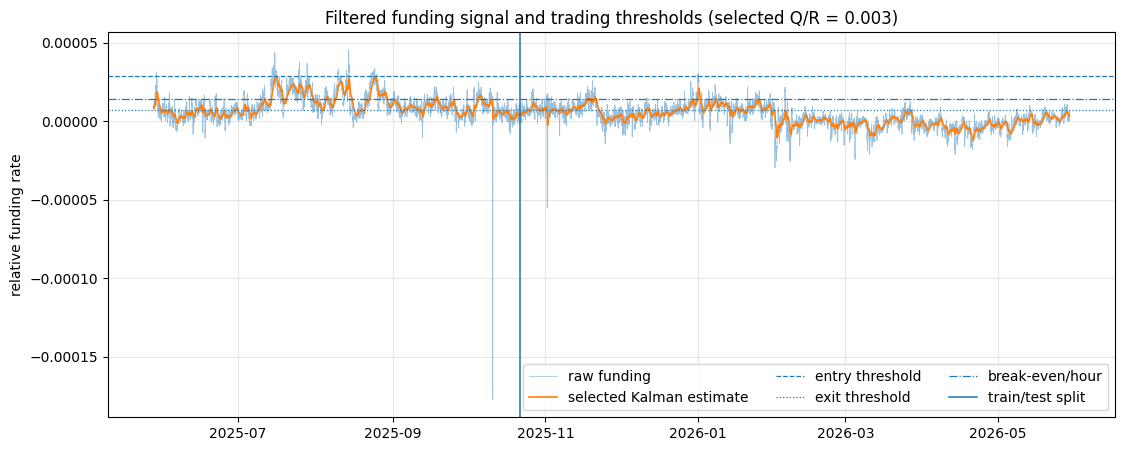

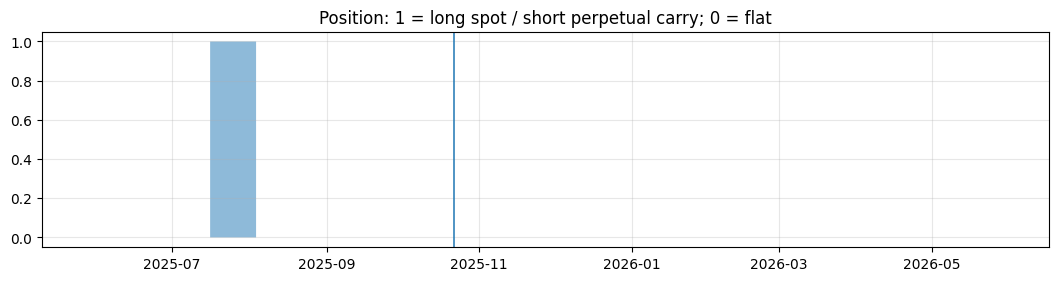

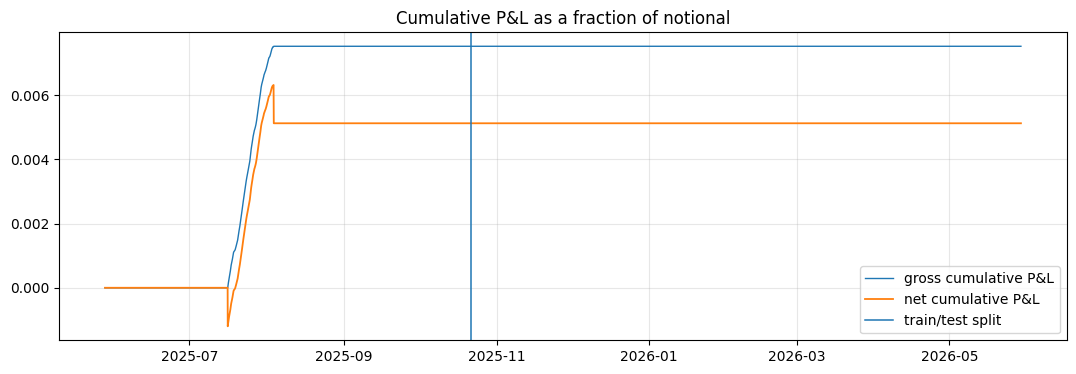

In [19]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(full_bt.index, full_bt["funding"], linewidth=0.55, alpha=0.45, label="raw funding")
ax.plot(full_bt.index, full_bt["x_hat"], linewidth=1.2, label="selected Kalman estimate")
ax.axhline(entry_threshold, linestyle="--", linewidth=0.9, label="entry threshold")
ax.axhline(exit_threshold, linestyle=":", linewidth=0.9, label="exit threshold")
ax.axhline(breakeven_per_hour, linestyle="-.", linewidth=0.9, label="break-even/hour")
ax.axvline(full_bt.index[split_idx], linewidth=1.1, label="train/test split")
ax.set_title(f"Filtered funding signal and trading thresholds (selected Q/R = {best_Q / best_R:g})")
ax.set_ylabel("relative funding rate")
ax.legend(ncol=3)
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(13, 2.8))
ax.fill_between(full_bt.index, 0, full_bt["pos"], step="pre", alpha=0.5)
ax.axvline(full_bt.index[split_idx], linewidth=1.1)
ax.set_ylim(-0.05, 1.05)
ax.set_title("Position: 1 = long spot / short perpetual carry; 0 = flat")
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(full_bt.index, full_bt["pnl_gross"].cumsum(), linewidth=1.0, label="gross cumulative P&L")
ax.plot(full_bt.index, full_bt["equity"], linewidth=1.3, label="net cumulative P&L")
ax.axvline(full_bt.index[split_idx], linewidth=1.1, label="train/test split")
ax.set_title("Cumulative P&L as a fraction of notional")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 12. Inspect selected trades

Each row below is an entry or exit event. The cost is charged on position changes; funding P&L is earned according to the position that was already in place before the realised funding bar.

In [20]:
trade_events = full_bt.loc[full_bt["turnover"] > 0, [
    "funding", "x_hat", "pos", "turnover", "costs", "pnl", "equity"
]].copy()

display(trade_events.head(20))
print(f"Total position-change events: {len(trade_events)}")
print(f"Entries: {(trade_events['pos'] == 1).sum()}")
print(f"Exits:   {(trade_events['pos'] == 0).sum()}")

,funding,x_hat,pos,turnover,costs,pnl,equity
timestamp,,,,,,,
2025-07-16 10:00:00+00:00,0.00003147,0.00002861,1.00000000,1.00000000,0.00120000,-0.00120000,-0.00120000
2025-08-03 19:00:00+00:00,0.00000623,0.00000712,0.00000000,1.00000000,0.00120000,-0.00119377,0.00512766


Total position-change events: 2
Entries: 1
Exits:   1


## 13. Parameter playground

This cell makes it easy to study a particular $Q/R$ value without changing the train/test result above. Change `ratio_to_study`, run the cell again, and inspect how trading frequency, responsiveness, and net outcome change.

,Study Q/R=0.001
bars,"8,783.00000000"
entries,0.00000000
time in position,0.00000000
gross P&L (fraction of notional),0.00000000
cost drag,0.00000000
net P&L (fraction of notional),0.00000000
annualised Sharpe,NaN
max drawdown,0.00000000


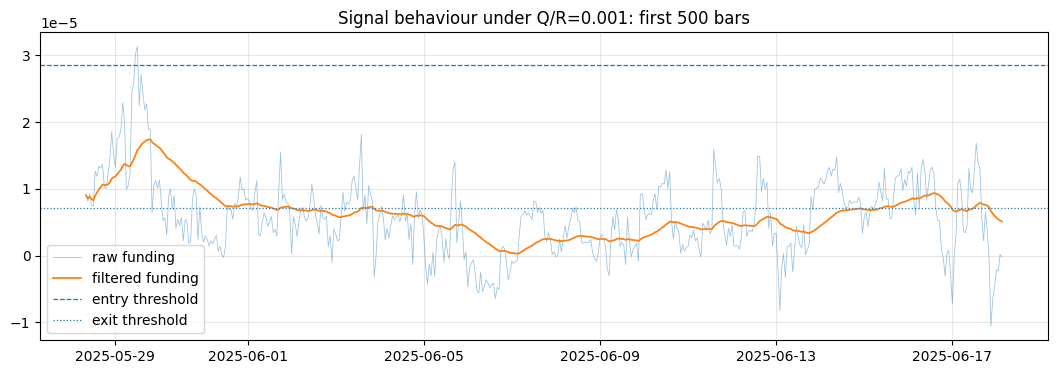

In [21]:
ratio_to_study = 1e-3   # Try: 1e-4, 1e-3, 1e-2, 1e-1
Q_to_study = ratio_to_study * R_BELIEF

study_diag = filter_with_diagnostics(funding, Q_to_study, R_BELIEF)
study_bt = backtest(
    funding,
    study_diag["x_hat"].to_numpy(),
    entry_threshold,
    exit_threshold,
    index=funding_df.index,
)

display(performance_report(study_bt, f"Study Q/R={ratio_to_study:g}").to_frame())

window = min(500, len(study_bt))
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(study_bt.index[:window], study_bt["funding"].iloc[:window], linewidth=0.55, alpha=0.45, label="raw funding")
ax.plot(study_bt.index[:window], study_bt["x_hat"].iloc[:window], linewidth=1.25, label="filtered funding")
ax.axhline(entry_threshold, linestyle="--", linewidth=0.9, label="entry threshold")
ax.axhline(exit_threshold, linestyle=":", linewidth=0.9, label="exit threshold")
ax.set_title(f"Signal behaviour under Q/R={ratio_to_study:g}: first {window} bars")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 14. What this notebook demonstrates, and what remains simplified

What is implemented:

- A scalar Kalman filter for a random-walk latent funding level.
- A causal filtered signal based only on observations available by each time.
- A long-spot / short-perpetual carry position.
- Hysteresis thresholds derived from a simple transaction-cost break-even yardstick.
- A chronological training/test split.
- Training-only selection of the $Q/R$ smoothing ratio.

Important simplifications:

- $Q/R$ is selected for historical trading performance, not estimated as the true statistical data-generating process.
- The model uses a fixed round-trip trading cost and an assumed one-week holding-period break-even yardstick.
- It does not explicitly model slippage, borrowing/financing costs, margin, liquidation risk, basis risk, exchange risk, or execution latency.
- The one-for-one hedge is treated as structurally delta neutral.
- A single train/test split is informative but weaker than repeated walk-forward evaluation.

Useful next research steps:

1. Replace the single split with walk-forward tuning and evaluation.
2. Add realistic spot/perpetual fee and slippage assumptions.
3. Compare filtered-signal trading with raw-signal trading.
4. Estimate $Q$ and $R$ by likelihood, then compare those values with strategy-tuned values.
5. Model funding sign, settlement timing, and exchange mechanics explicitly before treating results as implementable.

,TEST: raw funding signal,TEST: Kalman-filtered signal
bars,"5,270.00000000","5,270.00000000"
entries,1.00000000,0.00000000
time in position,0.00303605,0.00000000
gross P&L (fraction of notional),0.00036541,0.00000000
cost drag,0.00240000,0.00000000
net P&L (fraction of notional),-0.00203459,0.00000000
annualised Sharpe,-1.54726766,NaN
max drawdown,-0.00203459,0.00000000


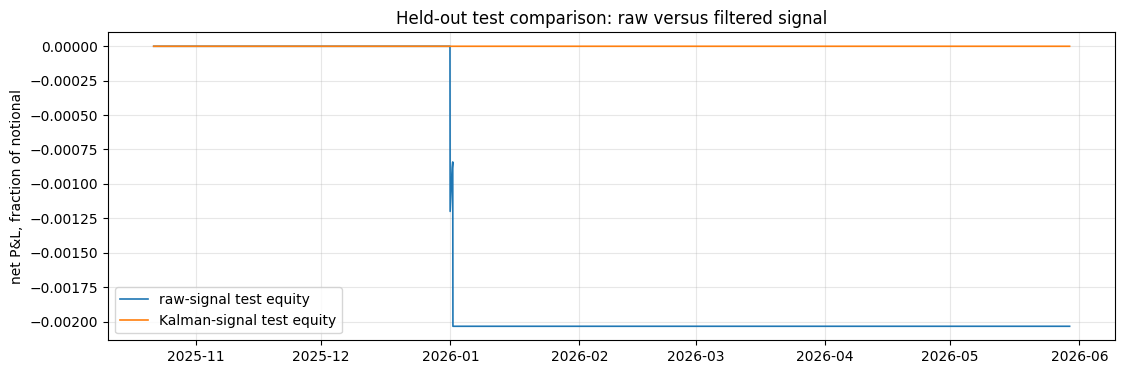

In [22]:
# Optional final comparison: raw signal versus selected Kalman signal
raw_signal_bt = backtest(
    funding,
    funding,  # use raw observation directly instead of a filtered estimate
    entry_threshold,
    exit_threshold,
    index=funding_df.index,
)

raw_test = raw_signal_bt.iloc[split_idx:].copy()
raw_test["equity"] = raw_test["pnl"].cumsum()

comparison_report = pd.concat([
    performance_report(raw_test, "TEST: raw funding signal"),
    performance_report(test_bt, "TEST: Kalman-filtered signal"),
], axis=1)

display(comparison_report)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(raw_test.index, raw_test["equity"], linewidth=1.2, label="raw-signal test equity")
ax.plot(test_bt.index, test_bt["equity"], linewidth=1.2, label="Kalman-signal test equity")
ax.set_title("Held-out test comparison: raw versus filtered signal")
ax.set_ylabel("net P&L, fraction of notional")
ax.legend()
ax.grid(alpha=0.3)
plt.show()